In [14]:
import numpy as np, matplotlib.pyplot as plt, scipy as sp
from dataclasses import dataclass
from scipy.special import hermite
from math import factorial
import torch

hbar = sp.constants.hbar
pi = sp.constants.pi

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon GPU (MPS) detected. Simulation will run on GPU.")
else:
    device = torch.device("cpu")
    print("MPS not available. Falling back to CPU.")

# Define simulation parameters

@dataclass
class GPE:

    debug = False

    high_precision = False

    if high_precision:
        complex_type = torch.complex128
        real_type = torch.float64

    else:
        complex_type = torch.complex64
        real_type = torch.float32
    



    Np=1e7
    m = 1.9e-25  #kg
    omega = 2 * pi * 40 #Hz
    a0 = 2e-9 #m
    g0 = 4*pi*hbar**2*a0* Np/m
    gamma = 1
    a02 = 2e-27
    g2 = 6*np.sqrt(5) * hbar**2 * a02 * Np / m
    sigma = 11e-6

    l = np.sqrt(hbar/(m * omega)) #length scale
    tau = 1/omega # time scale
    G0 = g0/(l**3*hbar*omega)
    G2 = g2/(hbar*omega*l**5)

    waist = False
    imag_waist = False
    cutoff = True
    

    #sim params

    up = 2.5 * sigma
    N = 256

    ev_time = 3e-3 #s
    time_steps = 10000

    x = torch.linspace(-up,up,N+1, device=device, dtype=real_type)[:-1] # avoid double counting endpoint 
    dx = (x[1]-x[0]).item(); dxu = dx/l

    X, Y, Z = torch.meshgrid(x,x,x, indexing='ij')
    uX,uY, uZ = X/l, Y/l, Z/l

    k = 2*pi*torch.fft.fftfreq(N, d=dx/l, device=device, dtype=real_type)
    KX, KY, KZ = torch.meshgrid(k,k,k, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z
    k_cutoff = pi/dx * (0.3) #m^-1


    
def sim_params(Np=GPE.Np, m=GPE.m, omega=GPE.omega, a0=GPE.a0, a02=GPE.a02, sigma=GPE.sigma, waist=GPE.waist, imag_waist=GPE.imag_waist, cutoff=GPE.cutoff, k_cutoff=GPE.k_cutoff, up=GPE.up, N=GPE.N, ev_time=GPE.ev_time, time_steps=GPE.time_steps):

    GPE.Np=Np
    GPE.m = m  #kg
    GPE.omega = omega #Hz
    GPE.a0 = a0 #m
    GPE.g0 = 4*pi*hbar**2*a0* Np/m
    GPE.gamma = 1
    GPE.a02 = a02
    GPE.g2 = 6*np.sqrt(5) * hbar**2 * a02 * Np / m
    GPE.sigma = sigma

    GPE.l = np.sqrt(hbar/(m * omega)) #length scale
    GPE.tau = 1/omega # time scale
    GPE.G0 = GPE.g0/(GPE.l**3*hbar*omega)
    GPE.G2 = GPE.g2/(hbar*omega*GPE.l**5)

    GPE.waist = waist
    GPE.imag_waist = imag_waist
    GPE.cutoff = cutoff
    GPE.k_cutoff = k_cutoff #m^-1

    #sim params

    GPE.up = 2.5 * sigma
    GPE.N = 256

    GPE.ev_time = ev_time #s
    GPE.time_steps = time_steps

    GPE.x = torch.linspace(-GPE.up,GPE.up,N+1, device=device, dtype=GPE.real_type)[:-1] # avoid double counting endpoint 
    GPE.dx = (GPE.x[1]-GPE.x[0]).item(); GPE.dxu = GPE.dx/GPE.l

    GPE.X, GPE.Y, GPE.Z = torch.meshgrid(GPE.x,GPE.x,GPE.x, indexing='ij')
    GPE.uX,GPE.uY, GPE.uZ = GPE.X/GPE.l, GPE.Y/GPE.l, GPE.Z/GPE.l

    GPE.k = 2*pi*torch.fft.fftfreq(GPE.N, d=GPE.dx/GPE.l, device=device, dtype=GPE.real_type)
    GPE.KX, GPE.KY, GPE.KZ = torch.meshgrid(GPE.k,GPE.k,GPE.k, indexing="ij")  # Note that spacing d, is adjusted to represent spacing in uX/Y/Z


def dprint(*args):
    if GPE.debug:
        print(*args)

Apple Silicon GPU (MPS) detected. Simulation will run on GPU.


In [12]:
GPE.g2/GPE.g0

np.float64(1.0676438151257656e-18)

In [13]:
   
# Define wavefunction: Gaussian ansatz 

def gaussian(x, y, z):
    sigma, dx = GPE.sigma, GPE.dx
    gaussian = torch.exp(-1*(x**2+y**2+z**2)/(2*sigma**2)).to(GPE.complex_type) # Gaussian ansatz exp(r^2/2sigma^2)
    norm = torch.sum(torch.abs(gaussian)**2) * dx**3
    gaussian *= (1/norm)**(1/2) 
    return gaussian

# Define operators

def trap_potential(x,y,z):
    gam = GPE.gamma
    return (1/2)*(x**2+y**2+gam**2*z**2) # Non-dimensionalized potential; Note that factor of i–it's built into the function

def g0_term(psi): # in position basis
    return GPE.G0 * torch.abs(psi)**2


def kinetic_energy(kx, ky, kz):
    return (1/2) * (kx**2 + ky**2 + kz**2) # KE already in momentum space

def quadrupole_term(psi, kx,ky,kz):

    psi_mag_fft = torch.fft.fftn(torch.abs(psi)**2)
    op = psi_mag_fft * ((1/3)*(kx**2+ky**2+kz**2) - kz**2)

    if GPE.cutoff:
        
        k2 = kx**2+ky**2+kz**2
        unitless_k = (GPE.k_cutoff * GPE.l)**2

        rho2 = kx**2+ky**2
        #mask = (k2 < (GPE.k_cutoff*GPE.l)**2)
        mask = (rho2 < unitless_k) & (kz**2 < unitless_k)

        op *=mask

        op = GPE.G2 * torch.real(torch.fft.ifftn(op))

        return op
    else:

        return GPE.G2 * torch.real(torch.fft.ifftn(op))
    
def wf_cutoff(wf, kx, ky, kz):

    assert GPE.cutoff == False, "Make sure potential cutoff is disabled if using wf_cutoff function"

    k2 = kx**2+ky**2+kz**2
    unitless_kc = (GPE.k_cutoff * GPE.l)

    mask = (k2 < unitless_kc**2)

    wf *= mask
    
    return wf

@torch.compile
def single_loop(wf, kx, ky, kz, potential_step, KE_step, dtau):

    wf *= potential_step
    q1 = quadrupole_term(wf, kx,ky,kz)
    wf *= torch.exp(-1j *(g0_term(wf) + q1) * (dtau/2))

    # Apply momentum-basis operators for interval dt

    wf = torch.fft.fftn(wf)
    
    wf *= KE_step
    # wf = wf_cutoff(wf, kx, ky, kz)

    wf = torch.fft.ifftn(wf)

    # Apply position-basis operators for interval dt/2

    wf *= potential_step
    q2 = quadrupole_term(wf, kx,ky,kz)
    wf *= torch.exp(-1j*(g0_term(wf) + q2) * (dtau/2))

    return wf

In [31]:
def compute_energy(wf, ux, uy, uz, kx, ky, kz):

    wf_fft = torch.fft.fftn(wf)
    laplacian = 1/2 * (kx**2 + ky**2 + kz**2)
    qd = quadrupole_term(wf, kx, ky, kz)
    KE = torch.sum(laplacian * torch.abs(wf_fft)**2).real * GPE.dxu**3/GPE.N**3
    PE = torch.sum(trap_potential(ux, uy, uz) * torch.abs(wf)**2).real * GPE.dxu**3
    g0E = 0.5 * torch.sum(g0_term(wf) * torch.abs(wf)**2).real * GPE.dxu**3
    qE = 0.5 * torch.sum(qd * torch.abs(wf)**2).real * GPE.dxu**3

    return KE.item(), PE.item(), g0E.item(), qE.item(), KE.item()+PE.item()+g0E.item()+qE.item()


def imag_evolution():

    ev_time = GPE.ev_time
    time_steps = GPE.time_steps

    dxu = GPE.dxu
    
    dt = ev_time/time_steps
    dtau = dt/GPE.tau * -1j # unitless imaginary-time step

    N = GPE.N
    X, Y, Z = GPE.X, GPE.Y, GPE.Z
    uX, uY, uZ = GPE.uX, GPE.uY, GPE.uZ
    KX, KY, KZ = GPE.KX, GPE.KY, GPE.KZ
    dx = GPE.dx
    l = GPE.l

    assert dx < l

    wf = gaussian(X, Y, Z)
    print("Psi normalization:", torch.sum(torch.abs(wf)**2 * dx**3).item())

    #Nondimensionalization
    wf = (wf * l**(3/2)).to(GPE.complex_type) # could we just nondimensionalize the coordinate grid rather than the wavefunction? TODO

    potential_step = torch.exp(-1j *(trap_potential(uX, uY, uZ)) * (dtau/2))
    KE_step = torch.exp(-1j*(kinetic_energy(KX, KY, KZ)) * dtau)

    converge = False; prev_energy = 1e10; counter = 0; energies = []

    while not converge:

        wf = single_loop(wf, KX, KY, KZ, potential_step, KE_step, dtau)
        norm = torch.sum(torch.abs(wf)**2 * dxu**3)
        wf *= (1/norm)**(1/2)

        energy = compute_energy(wf, uX, uY, uZ, KX, KY, KZ)
        energies.append(energy)
        total = energy[-1]

        if abs(total - prev_energy)/abs(total) < 1e-6:
            break
        
        counter += 1

        if counter % 10 == 0:
            dprint(f"Energy: {total}, change: {abs(total-prev_energy)/abs(total)}, step: {counter}, norm: {norm}")

        prev_energy = total

    # Redimensionalize result

    redim_wf = wf* GPE.l**(-3/2)

    redim_wf = redim_wf.cpu().numpy()
    wf = wf.cpu().numpy()

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*GPE.dx**3)

    return redim_wf, wf, energies

In [32]:
#imaginary time evolution to find ground state

a02_vals = np.linspace(0, 2e-21, 10)

a02_energies = []

for val in a02_vals:
    sim_params(a02=val)
    print(GPE.a02, GPE.g2, GPE.G2)
    redim_wf, wf, energies = imag_evolution()
    a02_energies.append(energies[-1])

0.0 0.0 0.0
Psi normalization: 1.0000001192092896
Final WF normalization 0.9999998
2.222222222222222e-22 1.7451086049012473e-57 9084.471946494663
Psi normalization: 1.0000001192092896
Final WF normalization 1.0000005
4.444444444444444e-22 3.4902172098024946e-57 18168.943892989326
Psi normalization: 1.0000001192092896
Final WF normalization 1.0
6.666666666666666e-22 5.235325814703742e-57 27253.41583948399
Psi normalization: 1.0000001192092896
Final WF normalization 1.0
8.888888888888888e-22 6.980434419604989e-57 36337.88778597865
Psi normalization: 1.0000001192092896
Final WF normalization 1.0000001
1.111111111111111e-21 8.725543024506238e-57 45422.35973247332
Psi normalization: 1.0000001192092896
Final WF normalization 0.99999964
1.3333333333333333e-21 1.0470651629407484e-56 54506.83167896798
Psi normalization: 1.0000001192092896
Final WF normalization 1.0000001
1.5555555555555556e-21 1.2215760234308732e-56 63591.30362546265
Psi normalization: 1.0000001192092896
Final WF normalization 

In [26]:
GPE.a02 = 2e-22
print(GPE.g2)
GPE.a02 = 1e-21
print(GPE.g2)

1.0361582341601158e-57
1.0361582341601158e-57


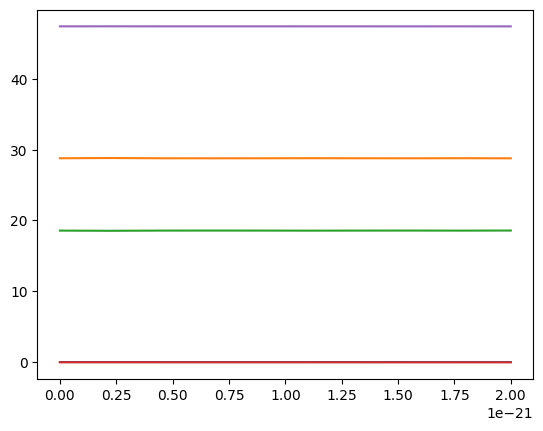

In [33]:
times = np.linspace(0, GPE.ev_time, len(energies))
#plt.plot(times, energies)
plt.plot(a02_vals, a02_energies)

129


In [15]:
def evolution(ground_state=False):

    ev_time = GPE.ev_time
    time_steps = GPE.time_steps

    dxu = GPE.dx/GPE.l
    
    dt = ev_time/time_steps
    dtau = dt/GPE.tau # unitless time step
    

    print("time scale:", GPE.tau)
    print("unitless time: ", ev_time/GPE.tau)
    print("unitless distance:", GPE.up/GPE.l)
    print("time resolution:", dtau)
    print("space resolution:", dxu)

    X, Y, Z = GPE.X, GPE.Y, GPE.Z
    uX, uY, uZ = GPE.uX, GPE.uY, GPE.uZ
    KX, KY, KZ = GPE.KX, GPE.KY, GPE.KZ
    dx = GPE.dx
    l = GPE.l

    assert dx < l

    wf = gaussian(X, Y, Z)
    if ground_state: wf = imag_evolution()[0]
    print("Psi normalization:", torch.sum(torch.abs(wf)**2 * dx**3).item())

    #Nondimensionalization
    wf = (wf * l**(3/2)).to(GPE.complex_type)

    potential_step = torch.exp(-1j *(trap_potential(uX, uY, uZ)) * (dtau/2))
    KE_step = torch.exp(-1j*(kinetic_energy(KX, KY, KZ)) * dtau)

    waist = []; uR2 = uX**2+uY**2+uZ**2

    for i in range(time_steps):

        wf = single_loop(wf, KX, KY, KZ, potential_step, KE_step, dtau)

        if i % (time_steps//10) == 0: print("Roughly {}% done".format(i/time_steps*100))

        if GPE.waist: waist.append(np.sum(np.abs(wf)**2 * uR2)*dxu**3) 
        
    waist = np.array(waist) * GPE.l**2
    
    # Redimensionalize result

    redim_wf = wf* GPE.l**(-3/2)

    redim_wf = redim_wf.cpu().numpy()
    wf = wf.cpu().numpy()

    print("Final WF normalization", np.sum(np.absolute(redim_wf)**2)*GPE.dx**3)

    return redim_wf, wf, waist

time scale: 0.0039788735772973835
unitless time:  0.7539822368615504
unitless distance: 18.505096049423265
time resolution: 7.539822368615503e-05
space resolution: 0.14457155171108957
Psi normalization: 1.0000001192092896
Roughly 0.0% done
Roughly 10.0% done
Roughly 20.0% done
Roughly 30.0% done
Roughly 40.0% done
Roughly 50.0% done
Roughly 60.0% done
Roughly 70.0% done
Roughly 80.0% done
Roughly 90.0% done
Final WF normalization 0.9891751


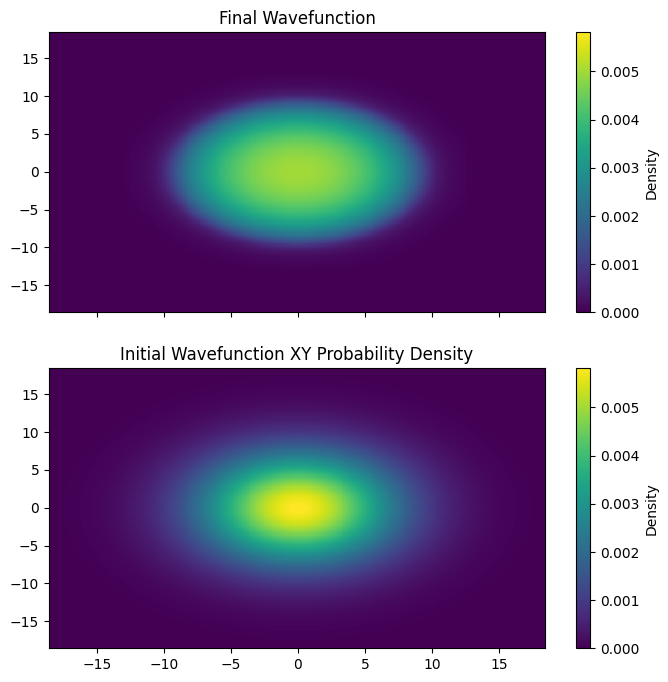

In [16]:
final_wf, wf, waist = evolution()

ev_time = GPE.ev_time
time_steps = GPE.time_steps
times = np.linspace(0, ev_time, time_steps)

x = GPE.x.cpu().numpy()
pX, pY = np.meshgrid(x, x, indexing='ij')

init_psi = gaussian(GPE.X, GPE.Y, GPE.Z).cpu().numpy()
initial_xy_density = np.sum(np.abs(init_psi)**2 * GPE.dx, axis=2)
u_initial_xy_density = np.sum(np.abs(init_psi*GPE.l**(3/2))**2 * GPE.dx/GPE.l, axis=2)

uxy_density = np.sum(np.abs(wf)**2 * GPE.dx/GPE.l, axis=2)
xy_density = np.sum(np.abs(final_wf)**2 * GPE.dx, axis=2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True) #, ax3, ax4, ax5

scale_max = max(np.max(u_initial_xy_density),np.max(uxy_density))

im1 = ax1.pcolormesh(pX/GPE.l, pY/GPE.l, uxy_density, vmin=0, vmax=scale_max)
ax1.set_title("Final Wavefunction")
fig.colorbar(im1, ax=ax1, label="Density")

im2 = ax2.pcolormesh(pX/GPE.l, pY/GPE.l, u_initial_xy_density, vmin=0, vmax=scale_max)
ax2.set_title("Initial Wavefunction XY Probability Density")
fig.colorbar(im2, ax=ax2, label="Density")

Text(0.5, 1.0, 'Final wavefunction slice at x=0')

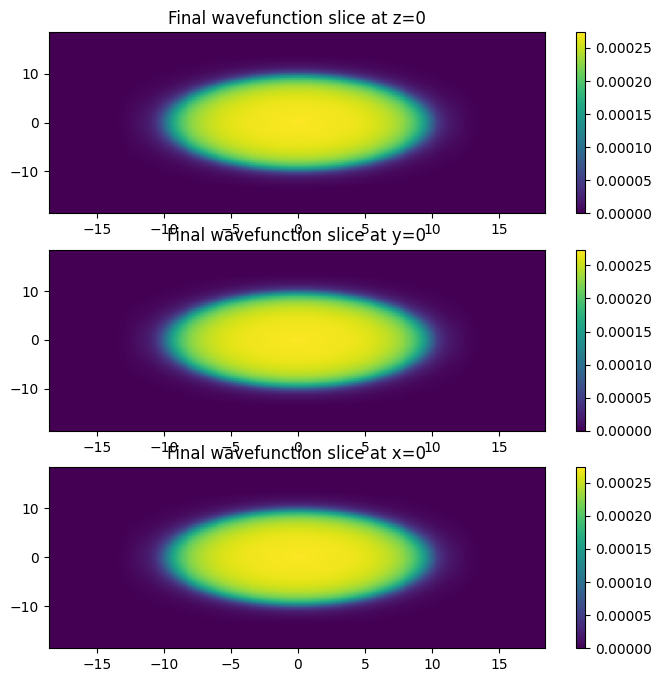

In [17]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=False)

im1 = ax1.pcolormesh(pX/GPE.l, pY/GPE.l, np.abs(wf[:,:,len(wf)//2])**2)
fig.colorbar(im1, ax=ax1)
ax1.set_title("Final wavefunction slice at z=0")

im2 = ax2.pcolormesh(pX/GPE.l, pY/GPE.l, np.abs(wf[:,len(wf)//2,:])**2)
fig.colorbar(im2, ax=ax2)
ax2.set_title("Final wavefunction slice at y=0")

im3 = ax3.pcolormesh(pX/GPE.l, pY/GPE.l, np.abs(wf[len(wf)//2,:,:])**2)
fig.colorbar(im3, ax=ax3)
ax3.set_title("Final wavefunction slice at x=0")
